In [1]:
%matplotlib widget 
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 

Im am going to try and plot the decay of an evanescent wave electric field along the z axis. Then I am going to try to plot the the the oscillations of its electric field along the x axis. Then I am going to try and combine the graphs using matplot3d.actually funcplot seems to be able to handle enough argument but it would be nice to make it 3d later on. 

I am going to the the eqautions from Hect because they are in a more covenient form. 

$$E_t=E_{0t}e^{+-\beta y}e^{i(k_txsin\theta_i /n_{ti}-\omega t)}$$

hect uses some new terms we dont have in our previose code. n_ti is his way of saying n_t. we also have our attenuation coefficient $\beta$. 
$$\beta =\frac{2 \pi n_t }{ \lambda _0}(\frac{n_i^2}{n_t^2}sin^2\theta_i -1)^{\frac{1}{2}}$$ 

When I go to code this will code a seperate function for beta but I will use its expanded form in my electric field eqaution because last time i tried to put a function in a function it didnt work. 

$\lambda_0$ is the wavelength of our light in vaccum. we will choose this somewhere in the infared range. Later on we can change it to be in the x-ray range because for them $n_{air}>n_{glass}$ 

$k_t$ is the magnitude of the transmitted wave vector. $k_t=\frac{2\pi n_t}{\lambda_0}$

Now I am going to simplify the eqaution into something codeable. 
$$E_t=E_{0t}e^{+-\beta y}e^{i(k_txsin\theta_i /n_{ti}-\omega t)}$$
drop the plus minus from beta and use euler's formula.
$$E_t=E_{0t}e^{-\beta y}(cos(k_txsin\theta_i /n_{ti}-\omega t)+isin(k_txsin\theta_i /n_{ti}-\omega t))$$
$$Re(E_t)= E_{0t}e^{-\beta y}cos(k_txsin\theta_i /n_{ti}-\omega t)$$ 
Since we are using a fixed moment in time t=0 so wich gets rid of $-\omega t$
$$Re(E_t)= E_{0t}e^{-\beta y}cos(k_txsin\theta_i /n_{ti})$$ 
finally I can substitute in for beta and K_t
$$Re(E_t)= E_{0t}e^{-\frac{2 \pi n_t }{ \lambda _0}(\frac{n_i^2}{n_t^2}sin^2\theta_i -1)^{\frac{1}{2}} y}cos(\frac{2\pi n_t}{\lambda_0}xsin\theta_i /n_{ti})$$ 

I am going to use meters for my units of x and y wich may need to be really small. I am not sure how to deal with $E_{0t}$ yet. You can calculate it using t ftom the fresnell coefficients and $E_{0i}$ but im going to set it eqaul to 1 for now. 

I am also goung to change some of the funcplot code. 

In [2]:
def EVDeacayplot1(func1,):
    fig0 = plt.figure(figsize=(8,5))
    ax0 = fig0.add_subplot(111)
    thi = np.linspace(42,89.9,10000)
    line01, = ax0.plot([],[], 'r-')
    ax0.set_xlim((42,90))
    ax0.set_ylim((0,1))
    ax0.axhline(0, linewidth=0.75, color='k')
    # ax0.axvline(0, color='k')
    ax0.set_xlabel(r'$\theta_i$')
    ax0.set_ylabel('E_t amplitude')
    ax0.legend([r'Re(E_t)',],)
    def plot(ni=1.5, nt=1, y=0, x=0):
        output1 = func1(ni, nt, y, x, thi)
        line01.set_data(thi, output1)
        plt.draw()
    interact(plot, ni=(0,5,.1), nt=(0,5,.1), y=(0,1000,.1), x=(0,20,.1))  

def sin(th):
    return np.sin(th*np.pi/180)

def cos(th):
    return np.cos(th*np.pi/180)

def arcsin(ratio):
    return np.arcsin(ratio)*180/np.pi

def snells(ni, nt, ki, kt, thi):
    return(arcsin((ni+1j*ki)/(nt+1j*kt)*sin(thi)))

def costht(ni, nt, ki, kt, thi):
    return(np.sqrt(1-((ni+1j*ki)/(nt+1j*kt)*sin(thi))**2))
    # return(1j*np.sqrt(((ni+1j*ki)/(nt+1j*kt)*sin(thi))**2-1-0j))
    
def ReE_t(ni, nt, y, x, thi, lamb_0=1000, E_0t=1):
    return(E_0t*np.exp((-2*np.pi*nt)/(lamb_0)*((ni**2)/(nt**2)*(sin(thi))**2-1)**(1/2)*y)*(cos(np.pi*2*nt/lamb_0*x*sin(thi)/nt)))






interactive(children=(FloatSlider(value=1.5, description='ni', max=5.0), FloatSlider(value=1.0, description='n…

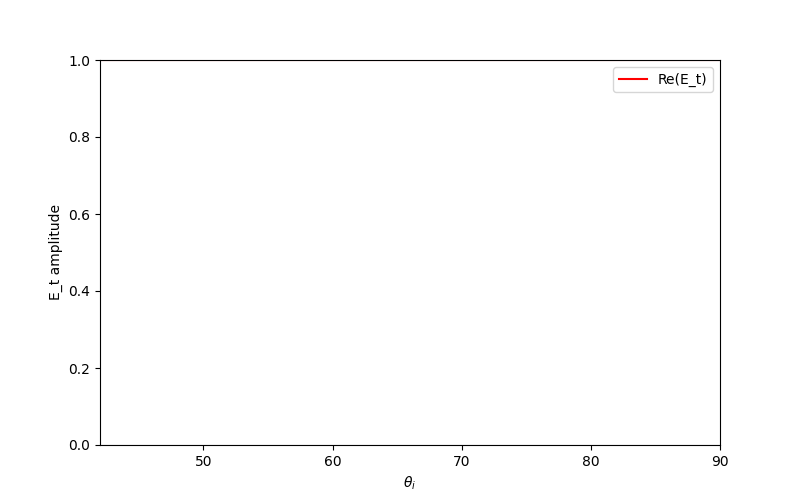

In [4]:
EVDeacayplot1(ReE_t)

The above graph is plotting the values across a changing theta. I want my to have y on the bottom axis. also my value for lambda_0 is way off. I have it set at 1000 but that's in nanometers. Changing it to 800*e^-7 or .0000008. Also i am adjusting my x and y values accordingly. nevermind im converting everything to nanometers

In [5]:
def EVDeacayplot2(func1,):
    fig0 = plt.figure(figsize=(8,5))
    ax0 = fig0.add_subplot(111)
    thi = np.linspace(42,89.9,10000)
    line01, = ax0.plot([],[], 'r-')
    ax0.set_xlim((0,1000))
    ax0.set_ylim((0,1))
    ax0.axhline(0, linewidth=0.75, color='k')
    # ax0.axvline(0, color='k')
    ax0.set_xlabel(r'y')
    ax0.set_ylabel('E_t amplitude')
    ax0.legend([r'Re(E_t)',],)
    def plot(ni=1.5, nt=1, x=0, thi=43):
        y = np.linspace(0.1, 1000, 10000)
        output1 = func1(ni, nt, y, x, thi)
        line01.set_data(y, output1)
        plt.draw()
    interact(plot, ni=(0,5,.1), nt=(0,5,.1), x=(0,1000,.1), thi=(43,89.9,.1))  

def sin(th):
    return np.sin(th*np.pi/180)

def cos(th):
    return np.cos(th*np.pi/180)

def arcsin(ratio):
    return np.arcsin(ratio)*180/np.pi

def snells(ni, nt, ki, kt, thi):
    return(arcsin((ni+1j*ki)/(nt+1j*kt)*sin(thi)))

def costht(ni, nt, ki, kt, thi):
    return(np.sqrt(1-((ni+1j*ki)/(nt+1j*kt)*sin(thi))**2))
    # return(1j*np.sqrt(((ni+1j*ki)/(nt+1j*kt)*sin(thi))**2-1-0j))
    
def ReE_t(ni, nt, y, x, thi, lamb_0=800, E_0t=1):
    return(E_0t*np.exp((-2*np.pi*nt)/(lamb_0)*((ni**2)/(nt**2)*(sin(thi))**2-1)**(1/2)*y)*(cos(np.pi*2*nt/lamb_0*x*sin(thi)/nt)))






interactive(children=(FloatSlider(value=1.5, description='ni', max=5.0), FloatSlider(value=1.0, description='n…

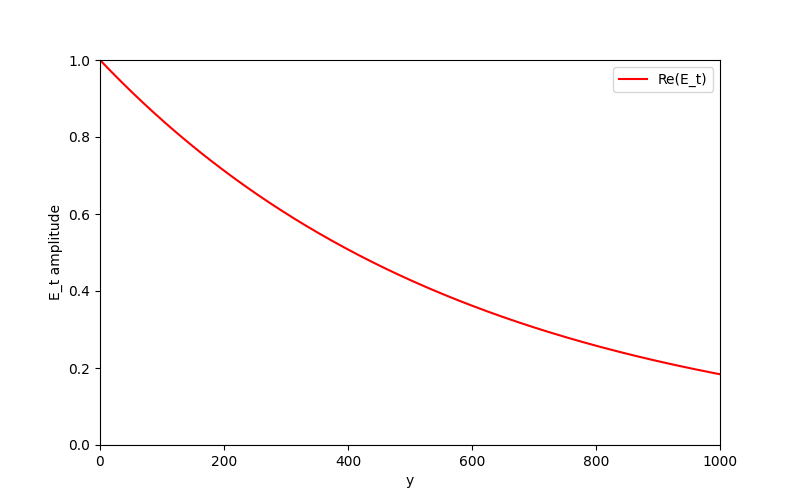

In [6]:
EVDeacayplot2(ReE_t)

now I need to fix my x variable. Im not seeing oscilations like i should when i mess with the slider. I think its because i haven't updated tha units. also there is a nt in the numerator and denominator of my cosine eqaution that can cancel. It may also be because im only graphing the real part. 

In [7]:
def EVDeacayplot3(func1,):
    fig0 = plt.figure(figsize=(8,5))
    ax0 = fig0.add_subplot(111)
    thi = np.linspace(42,89.9,10000)
    line01, = ax0.plot([],[], 'r-')
    ax0.set_xlim((0,1000))
    ax0.set_ylim((-1,1))
    ax0.axhline(0, linewidth=0.75, color='k')
    # ax0.axvline(0, color='k')
    ax0.set_xlabel(r'y')
    ax0.set_ylabel('E_t amplitude')
    ax0.legend([r'Re(E_t)',],)
    def plot(ni=1.5, nt=1, x=0, thi=43):
        y = np.linspace(0.1, 1000, 10000)
        output1 = func1(ni, nt, y, x, thi)
        line01.set_data(y, output1)
        plt.draw()
    interact(plot, ni=(0,5,.1), nt=(0,5,.1), x=(0,1000,.1), thi=(43,89.9,.1))  

def sin(th):
    return np.sin(th*np.pi/180)

def cos(th):
    return np.cos(th*np.pi/180)

def arcsin(ratio):
    return np.arcsin(ratio)*180/np.pi

def snells(ni, nt, ki, kt, thi):
    return(arcsin((ni+1j*ki)/(nt+1j*kt)*sin(thi)))

def costht(ni, nt, ki, kt, thi):
    return(np.sqrt(1-((ni+1j*ki)/(nt+1j*kt)*sin(thi))**2))
    # return(1j*np.sqrt(((ni+1j*ki)/(nt+1j*kt)*sin(thi))**2-1-0j))
    
def ReE_t(ni, nt, y, x, thi, lamb_0=800, E_0t=1):
    return(E_0t*np.exp((-2*np.pi*nt)/(lamb_0)*((ni**2)/(nt**2)*(sin(thi))**2-1)**(1/2)*y)*(np.cos(np.pi*2/lamb_0*x*sin(thi))))




interactive(children=(FloatSlider(value=1.5, description='ni', max=5.0), FloatSlider(value=1.0, description='n…

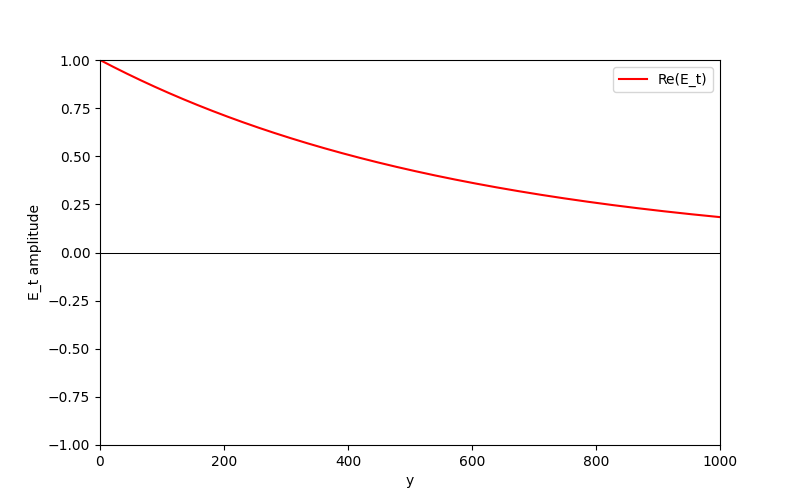

In [8]:
EVDeacayplot3(ReE_t)